In [2]:
#Packages load
import torch
import torch.nn as nn

from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader

import pandas as pd
from PIL import Image
import os

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import matplotlib.pyplot as plt

In [3]:
#Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
test_path = "/content/drive/MyDrive/MLS_DATA/test"

model_path = "/content/drive/MyDrive/MLS_DATA/"

In [6]:
#Image Transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [7]:
class CarlaDataset(Dataset):

    def __init__(self, data_path, label_column, transform=None):

        self.data_path = data_path
        self.transform = transform

        self.labels = pd.read_csv(
            os.path.join(data_path, "labels.csv")
        )

        self.label_column = label_column

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):

        row = self.labels.iloc[idx]

        frame = str(row['frame']).zfill(6)

        img_path = os.path.join(
            self.data_path,
            "rgb-front",
            f"{frame}.jpg"
        )

        image = Image.open(img_path).convert("RGB")

        label = int(row[self.label_column])

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
#Evaluation function
def evaluate_model(model_file, label_column):

    # Create dataset
    val_dataset = CarlaDataset(
        test_path,
        label_column=label_column,
        transform=transform
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False
    )

    # Create model
    model = models.resnet18(pretrained=True)

    model.fc = nn.Linear(
        model.fc.in_features,
        1
    )

    # Load weights
    model.load_state_dict(
        torch.load(model_file, map_location=device)
    )

    model = model.to(device)

    model.eval()

    # Prediction lists
    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels_batch in val_loader:

            images = images.to(device)

            outputs = model(images)

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).int()

            all_preds.extend(preds.cpu().numpy())

            all_labels.extend(labels_batch.numpy())

    # Flatten predictions
    all_preds = [p[0] for p in all_preds]

    # Metrics
    accuracy = accuracy_score(all_labels, all_preds)

    precision = precision_score(all_labels, all_preds)

    recall = recall_score(all_labels, all_preds)

    f1 = f1_score(all_labels, all_preds)

    return accuracy, precision, recall, f1

In [9]:
#loading all models
ped_metrics = evaluate_model(
    model_path + "pedestrian_model.pth",
    "has_pedestrian"
)

veh_metrics = evaluate_model(
    model_path + "Vehicle_model.pth",
    "has_vehicle"
)

traffic_metrics = evaluate_model(
    model_path + "Traffic_Light_model.pth",
    "has_traffic_light"
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 117MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other th

In [10]:
#CREATE COMPARISON TABLE
results = pd.DataFrame({

    "Model": [
        "Pedestrian",
        "Vehicle",
        "Traffic Light"
    ],

    "Accuracy": [
        ped_metrics[0],
        veh_metrics[0],
        traffic_metrics[0]
    ],

    "Precision": [
        ped_metrics[1],
        veh_metrics[1],
        traffic_metrics[1]
    ],

    "Recall": [
        ped_metrics[2],
        veh_metrics[2],
        traffic_metrics[2]
    ],

    "F1-score": [
        ped_metrics[3],
        veh_metrics[3],
        traffic_metrics[3]
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score
0,Pedestrian,0.818889,0.600746,0.228045,0.330595
1,Vehicle,0.861667,0.979948,0.832593,0.900280
2,Traffic Light,0.936389,0.939202,0.974458,0.956505


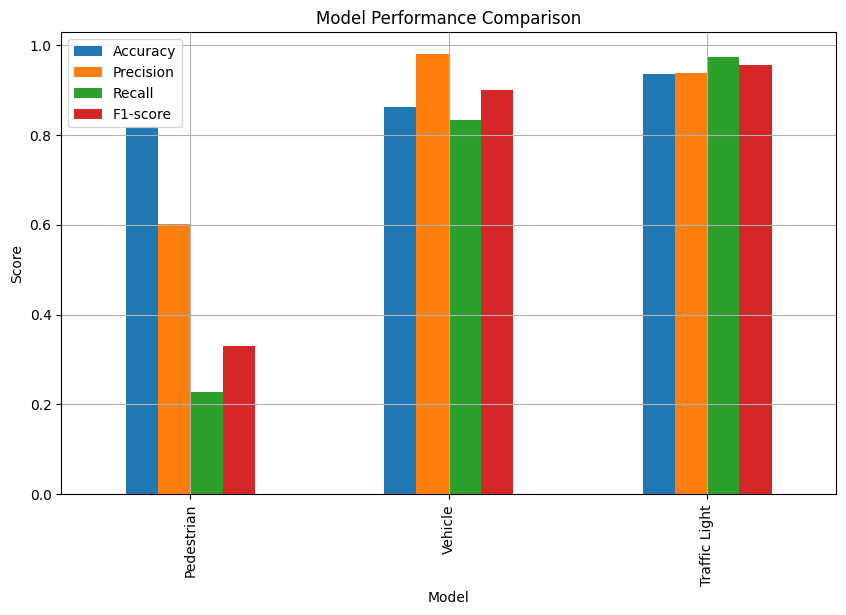

In [11]:
#PLOT COMPARSION
results.set_index("Model").plot(
    kind='bar',
    figsize=(10,6)
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")

plt.grid(True)

plt.show()